# CART for Parole Violation Prediction

In [127]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, roc_curve, auc, make_scorer, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
# We use graphviz for a better tree plot, similar to rpart.plot
from sklearn.tree import export_graphviz
from graphviz import Source
import graphviz
import math

In [128]:
# Data importation
# Assuming "NYCparole.csv" is in the working directory
parole = pd.read_csv("NYCparole.csv")

# Convert variables to factor/category as in R
# categorical_cols = ['Violator', 'Male', 'Class', 'Multiple', 'InCity']
categorical_cols = ['Violator', 'Class']
for col in categorical_cols:
    parole[col] = parole[col].astype('category')

# The target variable (Violator) must be 0/1 for scikit-learn .cat.codes converts the levels ('0', '1') to integers (0, 1)
parole['Violator'] = parole['Violator'].cat.codes

display(parole.head())

def show_head_tail(df, n=3, m=3):
    """
    Displays the head and tail of a DataFrame separated by an ellipsis.

    Args:
        df (pd.DataFrame): The DataFrame to display.
        n (int): The number of rows to show for the head and tail.
    """
    # Create a separator DataFrame filled with '...'
    separator = pd.DataFrame([['...'] * len(df.columns)],
                             columns=df.columns,
                             index=['...'])

    # Concatenate the head, separator, and tail
    combined_df = pd.concat([df.head(n), separator, df.tail(m)])

    display(combined_df)

# Take a look at the data
show_head_tail(parole[['Violator', 'Male', 'Age', 'Class', 'TimeServed', 'Multiple', 'InCity']], n=5, m=5)

,Violator,Male,Age,TimeServed,Class,Multiple,InCity
0,0,1,49.4,3.15,D,0,1
1,1,1,26.0,5.95,D,1,0
2,0,1,24.9,2.25,D,1,0
3,0,1,52.1,29.22,A,0,0
4,0,1,35.9,12.78,A,1,1


,Violator,Male,Age,Class,TimeServed,Multiple,InCity
0,0,1,49.4,D,3.15,0,1
1,1,1,26.0,D,5.95,1,0
2,0,1,24.9,D,2.25,1,0
3,0,1,52.1,A,29.22,0,0
4,0,1,35.9,A,12.78,1,1
...,...,...,...,...,...,...,...
6097,0,1,55.0,E,0.72,0,0
6098,0,1,49.6,A,29.88,0,1
6099,0,1,22.4,D,2.85,0,1
6100,0,1,44.8,D,1.76,1,0


In [129]:
# Prepare data for splitting
X_features = parole.drop('Violator', axis=1)
y_target = parole['Violator']

# Apply one-hot encoding on features (mirrors R's default model matrix creation)
# X = pd.get_dummies(X_features, drop_first=True)

# Split into a training set and a test set (70/30 stratified split)
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_target, test_size=0.3, stratify=y_target, random_state=140
)

# Combine for easier R-style subsetting (for the manual node checks later)
parole_train = X_train.copy()
parole_train['Violator'] = y_train
parole_test = X_test.copy()
parole_test['Violator'] = y_test

print("--- Training/Test Set Split ---")
print(f"Training set size: {len(parole_train)}")
print(f"Test set size: {len(parole_test)}")

--- Training/Test Set Split ---
Training set size: 4271
Test set size: 1831


In [130]:
#with pd.option_context('display.max_columns', 6):
#    show_head_tail(parole_train.sort_index()[['Violator', 'Male', 'Age', 'Class_B', 'Class_C', 'Class_D', 'Class_E', 'TimeServed', 'Multiple', 'InCity']], n=3, m=3)
#    show_head_tail(parole_test.sort_index()[['Violator', 'Male', 'Age', 'Class_B', 'Class_C', 'Class_D', 'Class_E', 'TimeServed', 'Multiple', 'InCity']], n=3, m=3)

In [131]:
# Logistic regression (GLM-style) with statsmodels and significance stars

def significance_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    elif p < 0.1:
        return '.'
    else:
        return ''

def print_summary_with_stars(model):
    summary_table = model.summary2().tables[1]
    # In Logit, statsmodels sometimes uses "P>|z|" instead of "P>|t|"
    p_col = "P>|z|" if "P>|z|" in summary_table.columns else "P>|t|"
    summary_table['Signif'] = summary_table[p_col].apply(significance_stars)

    # Round all numeric columns to 4 decimal places
    rounded_table = summary_table.round(4)

    # Get the string representation of the table with header
    table_string = rounded_table.to_string(header=True)

    # Split the string into lines
    lines = table_string.split('\n')

    # Print the header line
    print("=" * len(lines[0]))
    print(lines[0])
    # Print the separator line
    print("-" * len(lines[0]))
    # Print the rest of the table data
    print('\n'.join(lines[1:]))
    print("=" * len(lines[0]))

In [132]:
import statsmodels.formula.api as sm

# merge X and y into a single data frame for statsmodel formula
merged_train_df = pd.concat([X_train, y_train], axis=1)
display(merged_train_df.head())
feature_names = X_train.columns.tolist()

# Logistic regression
# parole_log = sm.logit(formula="Violator ~ Male + Age + Class_B + Class_C + Class_D + Class_E + TimeServed + Multiple + InCity", data=merged_train_df).fit(disp=False)
parole_log = sm.logit(formula=f"Violator ~ {' + '.join(feature_names)}", data=merged_train_df).fit(disp=False)
# print("--- Logistic Regression Summary ---")
print_summary_with_stars(parole_log)

,Male,Age,TimeServed,Class,Multiple,InCity,Violator
3419,1,23.8,2.37,D,1,0,0
2811,1,33.5,9.92,A,0,0,1
1891,1,64.3,19.65,C,0,0,0
3688,1,28.4,0.96,D,1,0,0
1494,1,49.3,2.86,B,1,1,0


             Coef.  Std.Err.        z   P>|z|  [0.025  0.975] Signif
--------------------------------------------------------------------
Intercept  -4.8159    0.6063  -7.9436  0.0000 -6.0041 -3.6276    ***
Class[T.B]  4.1857    0.4676   8.9523  0.0000  3.2693  5.1021    ***
Class[T.C]  4.1769    0.5102   8.1861  0.0000  3.1769  5.1770    ***
Class[T.D]  4.1521    0.5188   8.0031  0.0000  3.1353  5.1690    ***
Class[T.E]  4.1514    0.5424   7.6533  0.0000  3.0883  5.2146    ***
Male       -0.0745    0.2612  -0.2853  0.7754 -0.5865  0.4375       
Age        -0.0696    0.0085  -8.1479  0.0000 -0.0863 -0.0529    ***
TimeServed  0.1665    0.0151  11.0242  0.0000  0.1369  0.1961    ***
Multiple   -0.2221    0.1629  -1.3635  0.1727 -0.5415  0.0972       
InCity     -0.7124    0.1655  -4.3054  0.0000 -1.0368 -0.3881    ***


--- Fixed CART Model Plot (L=20, min_leaf=25, ccp_alpha=0.01) ---


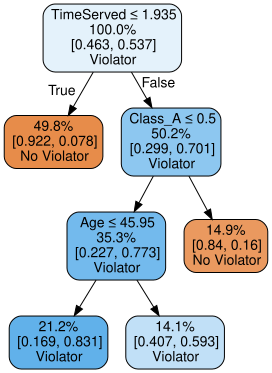

In [133]:
# Apply one-hot encoding on features
X = pd.get_dummies(X_features, drop_first=False)

# Split into a training set and a test set (70/30 stratified split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_target, test_size=0.3, stratify=y_target, random_state=140
)

# build a CART model with pre-specified values for ccp_alpha, minbucket, and loss
# L_FN=20, L_FP=1 -> class_weight={0: 1, 1: 20}
mod = DecisionTreeClassifier(
#     criterion="log_loss",
    min_samples_leaf=25,
    ccp_alpha=0.01,
    class_weight={0: 1, 1: 20},
    random_state=144,
)

mod.fit(X_train, y_train)

print("--- Fixed CART Model Plot (L=20, min_leaf=25, ccp_alpha=0.01) ---")
# Using graphviz for a better visualization
dot_data = export_graphviz(
    mod,
    out_file=None,
    feature_names=X_train.columns.tolist(),
    class_names=['No Violator', 'Violator'],
    filled=True,
    rounded=True,
    proportion=True,
    special_characters=True,
    impurity=False,
    label="none"
)
# Display the plot source
display(Source(dot_data))

In [134]:
import graphviz
import numpy as np
import re
from IPython.display import display

CLASS_COLORS = ['#ffaaaa', '#aaffaa', '#aaaaff', '#ffffaa', '#ffaaff']

def plot_tree_classifier_with_cats(model, feat_names, class_names, max_depth=3, title=None, cat_feat_indices=None, export=False):
    """
    Generates, displays, and optionally exports a customized decision tree plot.

    Args:
        model (DecisionTreeClassifier): The trained scikit-learn classification tree model.
        feat_names (list): A list of feature names.
        class_names (list): A list of class names (strings).
        max_depth (int): The maximum depth of the tree to display.
        title (str, optional): An optional title for the graph. Used for the filename if exporting.
        cat_feat_indices (list, optional): A list of feature indices that correspond
                                          to one-hot encoded (binary) categorical features.
        export (bool): If True, saves the tree diagram as a PNG image file in the
                       current directory. Defaults to False.
    """
    if cat_feat_indices is None:
        cat_feat_indices = []

    # Initialize graphviz Digraph
    dot = graphviz.Digraph(
        'tree_classifier',
        node_attr={'shape': 'box', 'style': 'rounded,filled', 'fontname': 'helvetica'},
        edge_attr={'fontname': 'helvetica', 'fontsize': '12'}
    )
    dot.attr('graph', rankdir='TB', label=title or '', fontname='helvetica', fontsize='16')

    tree_ = model.tree_

    def build_graph_recursive(node_id=0, depth=0):
        is_leaf = tree_.children_left[node_id] == tree_.children_right[node_id]

        value_array = tree_.value[node_id][0] # Get the array of class counts

        if is_leaf:
            # --- Leaf Node ---
            predicted_class_index = np.argmax(value_array)
            predicted_class_name = class_names[predicted_class_index]

            fill_color = CLASS_COLORS[predicted_class_index % len(CLASS_COLORS)]

            leaf_label = f"{predicted_class_name}"

            dot.node(str(node_id),
                     label=leaf_label,
                     shape='oval',
                     fillcolor=fill_color,
                     fontcolor='black')

        else:
            # --- Decision Node ---
            feature_index = tree_.feature[node_id]
            threshold = tree_.threshold[node_id]

            if feature_index in cat_feat_indices:
                split_condition = f"Is {feat_names[feature_index]} present?"
                true_label = 'Yes'
                false_label = 'No'
            else:
                split_condition = f"{feat_names[feature_index]} <= {threshold:.3f}"
                true_label = 'True'
                false_label = 'False'

            node_label = f"{split_condition}"

            dot.node(str(node_id), label=node_label, fillcolor='white')

            # --- Recurse or Add Ellipsis ---
            if depth < max_depth:
                left_child_id = tree_.children_left[node_id]
                right_child_id = tree_.children_right[node_id]

                dot.edge(str(node_id), str(left_child_id), label=true_label)
                dot.edge(str(node_id), str(right_child_id), label=false_label)

                build_graph_recursive(left_child_id, depth + 1)
                build_graph_recursive(right_child_id, depth + 1)
            else:
                # Add ellipsis for branches deeper than max_depth
                left_ellipsis_id = f"ellipsis_left_{node_id}"
                right_ellipsis_id = f"ellipsis_right_{node_id}"

                dot.node(left_ellipsis_id, label="...", shape='plaintext')
                dot.edge(str(node_id), left_ellipsis_id, label=true_label)

                dot.node(right_ellipsis_id, label="...", shape='plaintext')
                dot.edge(str(node_id), right_ellipsis_id, label=false_label)

    # --- Build, Display, and Optionally Export the Graph ---
    build_graph_recursive()

    # Always display the tree in the output cell
    display(dot)

    # If export is requested, save the file
    if export:
        # Create a filesystem-safe filename from the title
        if title:
            # Replace spaces and slashes with underscores, remove other invalid chars
            safe_title = re.sub(r'(?u)[^-\w.]', '', title.replace(' ', '_').replace('/', '_'))
            filename = f"tree_{safe_title}"
        else:
            # Use a generic name if no title is provided
            filename = "decision_tree_export"

        try:
            # The render method saves the file and returns the full path
            # cleanup=True removes the intermediate DOT source file after rendering
            output_path = dot.render(filename, format='png', cleanup=True)
            print(f"Tree successfully exported to: {output_path}")
        except Exception as e:
            # Catch errors if Graphviz executable is not installed or not in PATH
            print(f"Error exporting tree: {e}")
            print("Please ensure the Graphviz executable is installed and in your system's PATH.")

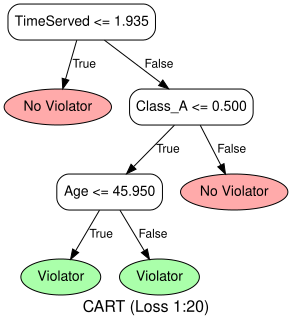

In [135]:
# Custom plotting

plot_tree_classifier_with_cats(
    mod,
    feat_names=X_train.columns.tolist(),
    class_names=['No Violator', 'Violator'],
    max_depth=math.inf,
    title="CART (Loss 1:20)"
)

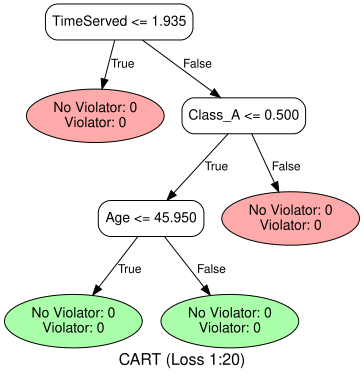

[Text(0.4, 0.875, 'x[2] <= 1.935\ngini = 0.497\nsamples = 4271\nvalue = [4037, 4680]'),
 Text(0.2, 0.625, 'gini = 0.144\nsamples = 2126\nvalue = [2117, 180]'),
 Text(0.30000000000000004, 0.75, 'True  '),
 Text(0.6, 0.625, 'x[5] <= 0.5\ngini = 0.419\nsamples = 2145\nvalue = [1920.0, 4500.0]'),
 Text(0.5, 0.75, '  False'),
 Text(0.4, 0.375, 'x[1] <= 45.95\ngini = 0.351\nsamples = 1507\nvalue = [1288, 4380]'),
 Text(0.2, 0.125, 'gini = 0.281\nsamples = 904\nvalue = [726, 3560]'),
 Text(0.6, 0.125, 'gini = 0.483\nsamples = 603\nvalue = [562, 820]'),
 Text(0.8, 0.375, 'gini = 0.268\nsamples = 638\nvalue = [632, 120]')]

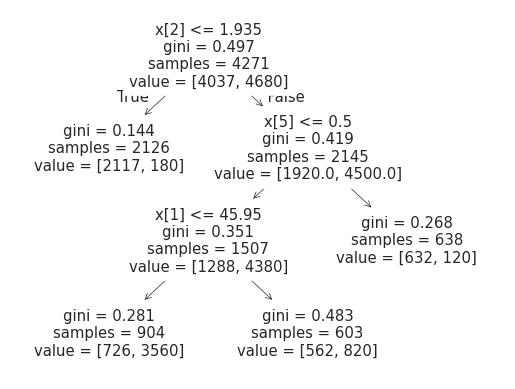

In [136]:
CLASS_COLORS = ['#ffaaaa', '#aaffaa', '#aaaaff', '#ffffaa', '#ffaaff']

def plot_tree_classifier_with_counts(model, feat_names, class_names, max_depth=3, title=None, cat_feat_indices=None, export=False):
    """
    Generates, displays, and optionally exports a customized decision tree plot
    with full class counts in each node.

    Args:
        model (DecisionTreeClassifier): The trained scikit-learn classification tree model.
        feat_names (list): A list of feature names.
        class_names (list): A list of class names (strings).
        max_depth (int): The maximum depth of the tree to display.
        title (str, optional): An optional title for the graph. Used for the filename if exporting.
        cat_feat_indices (list, optional): A list of feature indices that correspond
                                          to one-hot encoded (binary) categorical features.
        export (bool): If True, saves the tree diagram as a PNG image file in the
                       current directory. Defaults to False.
    """
    if cat_feat_indices is None:
        cat_feat_indices = []

    # Initialize graphviz Digraph
    dot = graphviz.Digraph(
        'tree_classifier',
        node_attr={'shape': 'box', 'style': 'rounded,filled', 'fontname': 'helvetica'},
        edge_attr={'fontname': 'helvetica', 'fontsize': '12'}
    )
    dot.attr('graph', rankdir='TB', label=title or '', fontname='helvetica', fontsize='16')

    tree_ = model.tree_

    def build_graph_recursive(node_id=0, depth=0):
        is_leaf = tree_.children_left[node_id] == tree_.children_right[node_id]

        # --- Common info for all nodes ---
        value_array = tree_.value[node_id][0] # Get the array of class counts
        class_counts = value_array.astype(int)
        # We still need this to determine the leaf color
        predicted_class_index = np.argmax(value_array)

        # Create the "Violator: X, Non Violator: Y" string
        count_lines = [f"{name}: {count}" for name, count in zip(class_names, class_counts)]
        counts_str = "\n".join(count_lines)

        if is_leaf:
            # --- Leaf Node ---
            fill_color = CLASS_COLORS[predicted_class_index % len(CLASS_COLORS)]

            leaf_label = f"{counts_str}"

            dot.node(str(node_id),
                     label=leaf_label,
                     shape='oval',
                     fillcolor=fill_color,
                     fontcolor='black')

        else:
            # --- Decision Node ---
            feature_index = tree_.feature[node_id]
            threshold = tree_.threshold[node_id]

            # Get the split condition
            if feature_index in cat_feat_indices:
                split_condition = f"Is {feat_names[feature_index]} present?"
                true_label = 'Yes'
                false_label = 'No'
            else:
                split_condition = f"{feat_names[feature_index]} <= {threshold:.3f}"
                true_label = 'True'
                false_label = 'False'

            node_label = f"{split_condition}"

            dot.node(str(node_id), label=node_label, fillcolor='white')

            # --- Recurse or Add Ellipsis ---
            # Use max_depth to control recursion
            if depth < max_depth:
                left_child_id = tree_.children_left[node_id]
                right_child_id = tree_.children_right[node_id]

                dot.edge(str(node_id), str(left_child_id), label=true_label)
                dot.edge(str(node_id), str(right_child_id), label=false_label)

                build_graph_recursive(left_child_id, depth + 1)
                build_graph_recursive(right_child_id, depth + 1)
            else:
                # Add ellipsis for branches deeper than max_depth
                left_ellipsis_id = f"ellipsis_left_{node_id}"
                right_ellipsis_id = f"ellipsis_right_{node_id}"

                dot.node(left_ellipsis_id, label="...", shape='plaintext')
                dot.edge(str(node_id), left_ellipsis_id, label=true_label)

                dot.node(right_ellipsis_id, label="...", shape='plaintext')
                dot.edge(str(node_id), right_ellipsis_id, label=false_label)

    # --- Build, Display, and Optionally Export the Graph ---
    build_graph_recursive()

    # Always display the tree in the output cell
    display(dot)

    # If export is requested, save the file
    if export:
        # Create a filesystem-safe filename from the title
        if title:
            # Replace spaces and slashes with underscores, remove other invalid chars
            safe_title = re.sub(r'(?u)[^-\w.]', '', title.replace(' ', '_').replace('/', '_'))
            filename = f"tree_{safe_title}"
        else:
            # Use a generic name if no title is provided
            filename = "decision_tree_export"

        try:
            # The render method saves the file and returns the full path
            # cleanup=True removes the intermediate DOT source file after rendering
            output_path = dot.render(filename, format='png', cleanup=True)
            print(f"Tree successfully exported to: {output_path}")
        except Exception as e:
            # Catch errors if Graphviz executable is not installed or not in PATH
            print(f"Error exporting tree: {e}")
            print("Please ensure the Graphviz executable is installed and in your system's PATH.")



plot_tree_classifier_with_counts(
    mod,
    feat_names=X_train.columns.tolist(),
    class_names=['No Violator', 'Violator'],
    max_depth=math.inf,
    title="CART (Loss 1:20)"
)

plot_tree(mod)

### CART trees for different $L_{FN}$ values

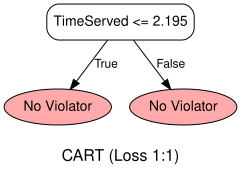

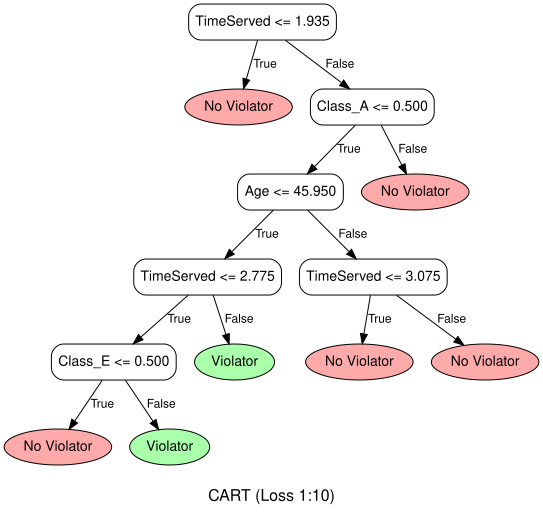

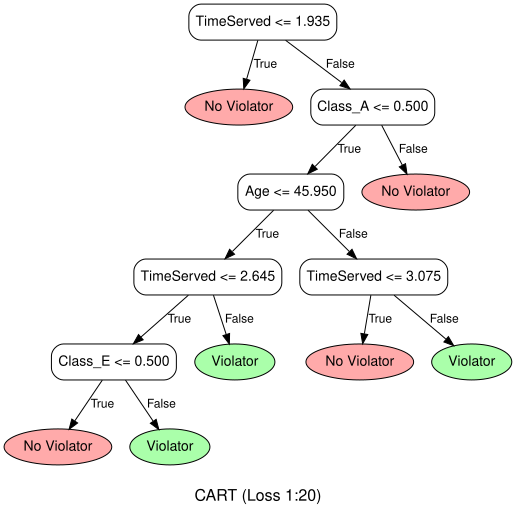

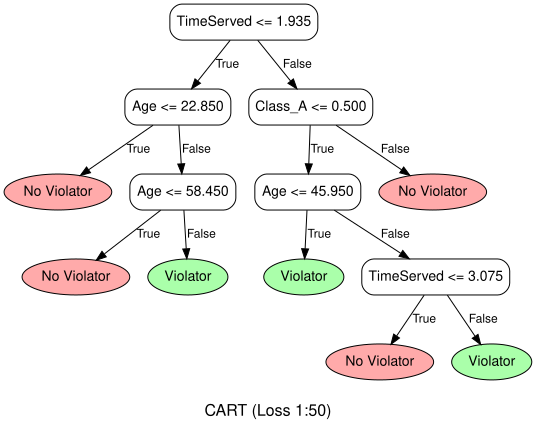

In [137]:
for L in [1,10,20,50]:
    mod = DecisionTreeClassifier(
        min_samples_leaf=5,
        ccp_alpha=0.005,
        class_weight={0: 1, 1: L},
        random_state=144,
    )
    mod.fit(X_train, y_train)
    plot_tree_classifier_with_cats(
        mod,
        feat_names=X_train.columns.tolist(),
        class_names=['No Violator', 'Violator'],
        max_depth=math.inf,
        title=f"\nCART (Loss 1:{L})\n"
    )

### Tree with only `TimeServed` and `Class`

--- Fixed CART Model Plot (L=20, min_leaf=25, ccp_alpha=0.01) ---


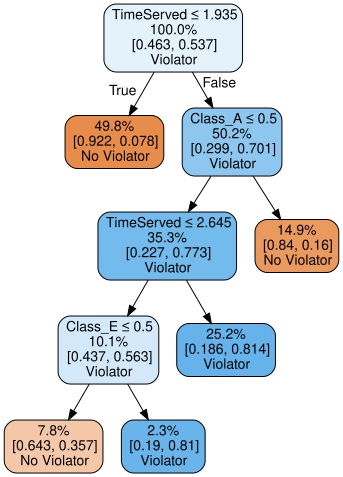

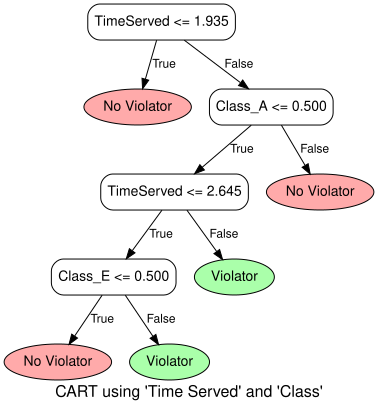

In [138]:
# build a CART model with pre-specified values for ccp_alpha, minbucket, and loss
# L_FN=20, L_FP=1 -> class_weight={0: 1, 1: 20}
mod = DecisionTreeClassifier(
    min_samples_leaf=25,
    ccp_alpha=0.01,
    class_weight={0: 1, 1: 20},
    random_state=144,
)

mod.fit(X_train[["TimeServed", "Class_A", "Class_B", "Class_C", "Class_D", "Class_E"]], y_train)

print("--- Fixed CART Model Plot (L=20, min_leaf=25, ccp_alpha=0.01) ---")
# Using graphviz for a better visualization
dot_data = export_graphviz(
    mod,
    out_file=None,
    feature_names=X_train[["TimeServed", "Class_A", "Class_B", "Class_C", "Class_D", "Class_E"]].columns.tolist(),
    class_names=['No Violator', 'Violator'],
    filled=True,
    rounded=True,
    proportion=True,
    special_characters=True,
    impurity=False,
    label="none"
)
# Display the plot source
display(Source(dot_data))

# Custom plotting

plot_tree_classifier_with_cats(
    mod,
    feat_names=X_train[["TimeServed", "Class_A", "Class_B", "Class_C", "Class_D", "Class_E"]].columns.tolist(),
    class_names=['No Violator', 'Violator'],
    max_depth=math.inf,
    title="CART using 'Time Served' and 'Class'"
)

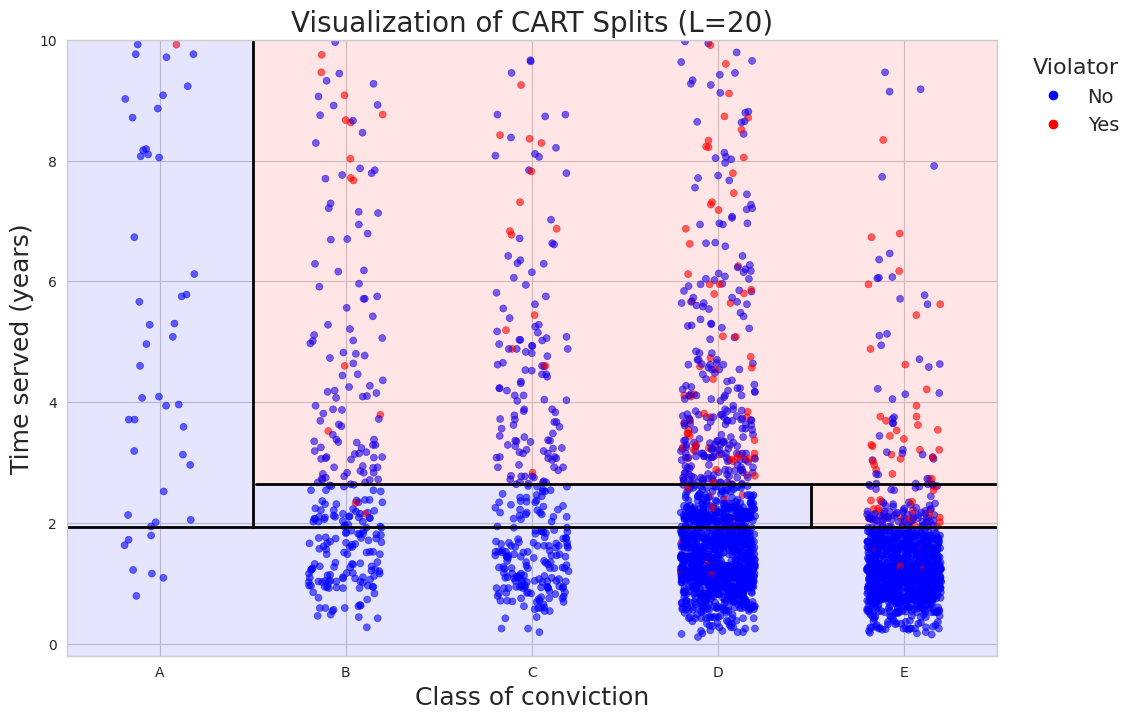

In [139]:
from matplotlib.lines import Line2D # Import for custom legend

# --- Visualization of Decision Boundaries using TimeServed and Class ---

# Recreate the data for plotting based on the R script's logic
# Map one-hot encoded 'Class' back to a single numeric column (A=1, B=2, C=3, D=4, E=5)
# Use the one-hot encoded X_train and y_train directly
parole_train_plot = X_train.copy()
parole_train_plot['Violator'] = y_train
parole_train_plot['Class_numeric'] = 1 # Start by assuming Class 'A' (the dropped level)
parole_train_plot.loc[parole_train_plot['Class_B'] == 1, 'Class_numeric'] = 2
parole_train_plot.loc[parole_train_plot['Class_C'] == 1, 'Class_numeric'] = 3
parole_train_plot.loc[parole_train_plot['Class_D'] == 1, 'Class_numeric'] = 4
parole_train_plot.loc[parole_train_plot['Class_E'] == 1, 'Class_numeric'] = 5

# Splits definition
My = 10
# The splits coordinates correspond to the L=20 tree shown
splits = {
    'y1': 1.935,
    'x1': 1.5,
    'y3': 2.645,
    'x4': 2.5,
    'x5': 4.5
}

plt.figure(figsize=(12, 8))
# 1. Jitter the x-axis points (R's jitter(as.numeric(Class)))
jitter_amount = 0.2
x_jitter = parole_train_plot['Class_numeric'] + np.random.uniform(-jitter_amount, jitter_amount, size=len(parole_train_plot))

# Scatter Plot
colors = parole_train_plot['Violator'].map({0: 'blue', 1: 'red'})
plt.scatter(
    x_jitter,
    parole_train_plot['TimeServed'],
    c=colors,
    s=25,
    alpha=0.6,
)

# Draw the final decision boundaries (R Lines 139-153)
# These lines correspond to the splits in the final L=20 tree

# Main bounding box lines (xA-xD) are omitted for clarity, but the limits are used
plt.axhline(splits['y1'], xmin=0/5.4, xmax=5.4/5.4, color='k', linewidth=2)

plt.plot([splits['x1'], splits['x1']], [splits['y1'], My], color='k', linewidth=2)

plt.axhline(splits['y3'], xmin=(splits['x1']-0.4)/5.4, xmax=5.4/5.4, color='k', linewidth=2)

plt.plot([splits['x5'], splits['x5']], [splits['y1'], splits['y3']], color='k', linewidth=2)


# Shaded Regions
# R1: TimeServed < 1.94 (Always blue/No Violator for L=20 tree)
plt.fill_between([0, 5.5], -0.2, splits['y1'], color='blue', alpha=0.1)

# R2: TimeServed >= 1.94 & Class='A' (Blue/No Violator)
plt.fill_between([0, splits['x1']], splits['y1'], My, color='blue', alpha=0.1)

# R3: TimeServed >= 2.78 & Class!='A' (Red/Violator)
plt.fill_between([splits['x1'], 5.5], splits['y3'], My, color='red', alpha=0.1)

# R4: 1.94 <= TimeServed < 2.78 & Class in ['B', C', 'D'] (Red/Violator)
plt.fill_between([splits['x1'], splits['x5']], splits['y1'], splits['y3'], color='blue', alpha=0.1)

# R5: 1.94 <= TimeServed < 2.78 & Class in ['E'] (Blue/No Violator)
plt.fill_between([splits['x5'], 5.5], splits['y1'], splits['y3'], color='red', alpha=0.1)


# Customize plot
plt.xlabel('Class of conviction', fontsize=18)
plt.ylabel('Time served (years)', fontsize=18)
plt.xticks(np.arange(1, 6), ['A', 'B', 'C', 'D', 'E'])
plt.ylim(-0.2, My)
plt.xlim(0.5, 5.5)
plt.title("Visualization of CART Splits (L=20)", fontsize=20)

# Add the custom legend, placed outside the plot
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='No', markerfacecolor='blue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Yes', markerfacecolor='red', markersize=8)
]
plt.legend(handles=legend_elements, title='Violator', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=14, title_fontsize=16)

plt.show()

### Trees for different `ccp_alpha` values (L=20, min_leaf=5)


--- Trees for different ccp_alpha values (L=20, min_leaf=5) ---

Tree for ccp_alpha=0 has 325 nodes.


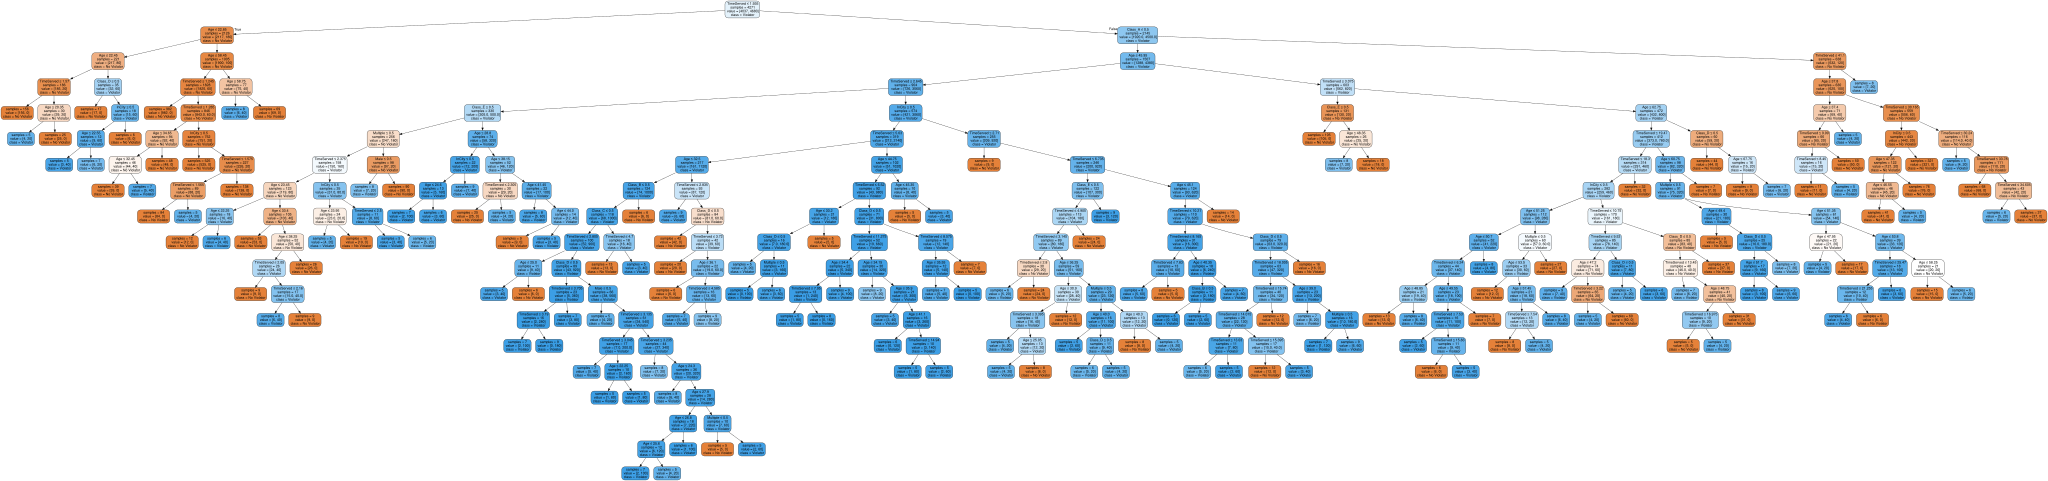

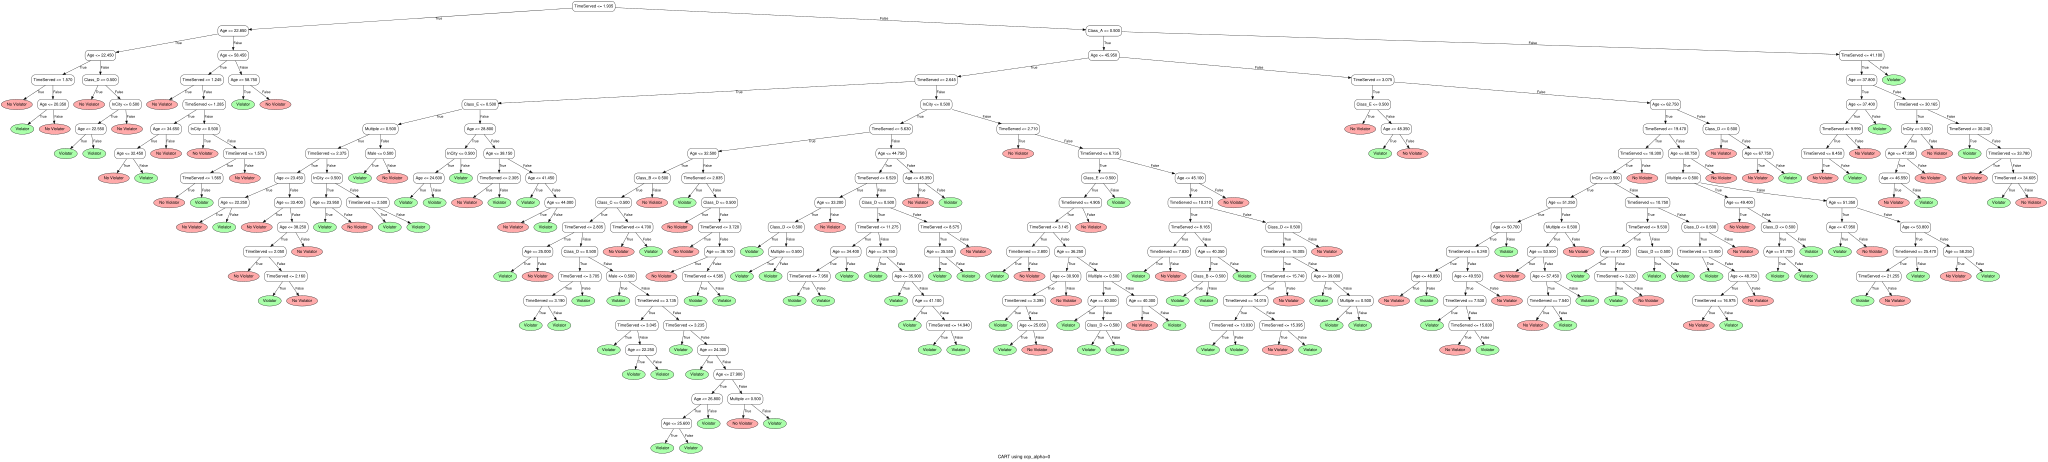

Tree successfully exported to: tree_CART_using_ccp_alpha0.png

Tree for ccp_alpha=0.005 has 13 nodes.


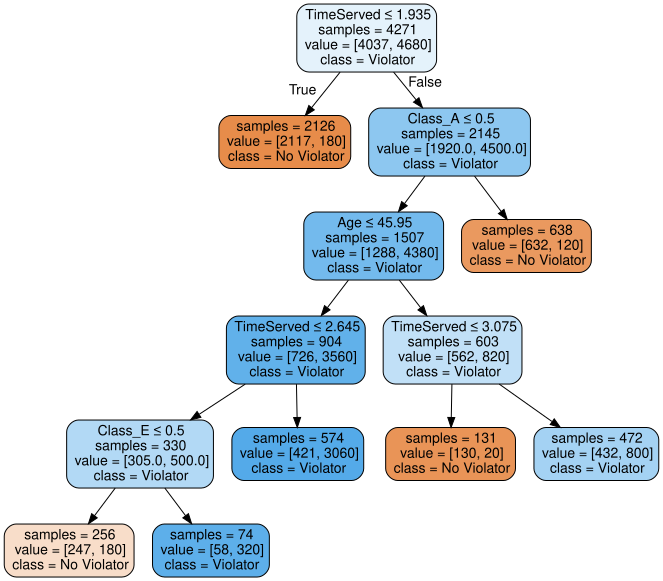

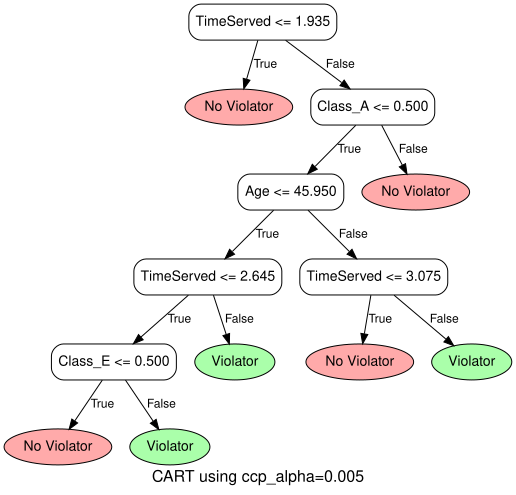


Tree for ccp_alpha=0.01 has 7 nodes.


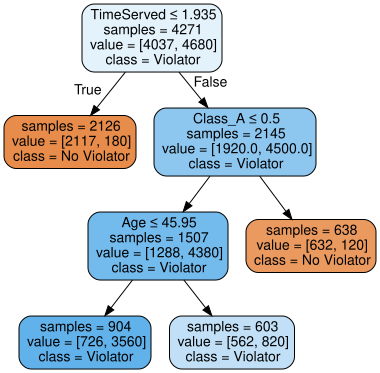

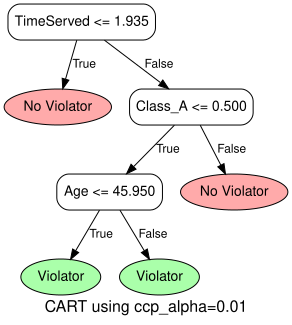


Tree for ccp_alpha=0.05 has 5 nodes.


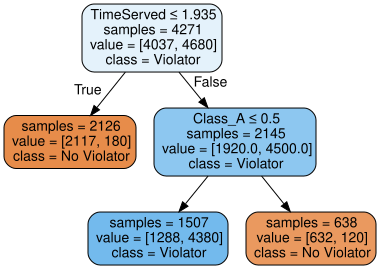

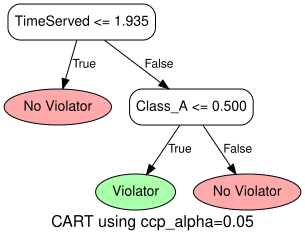


Tree for ccp_alpha=0.1 has 3 nodes.


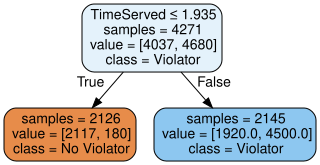

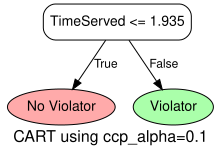


Tree for ccp_alpha=0.5 has 1 nodes.


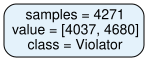

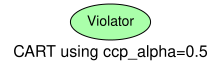

In [140]:
# # If we use minbucket = 1 and ccp_alpha = 0, it results in overfitting
# mod_overfitting = DecisionTreeClassifier(
#     min_samples_leaf=1,
#     ccp_alpha=0,
#     class_weight={0: 1, 1: 20},
#     random_state=144
# )
# mod_overfitting.fit(X_train, y_train)

# print(f"Overfitting Tree (ccp_alpha=0) has {mod_overfitting.tree_.node_count} nodes.")


# We generate trees with different values of cp (ccp_alpha)
cp_all = [0, 0.005, 0.01, 0.05, 0.1, 0.5]
print("\n--- Trees for different ccp_alpha values (L=20, min_leaf=5) ---")

for ccp_alpha in cp_all:
    tree = DecisionTreeClassifier(
        min_samples_leaf=5,
        ccp_alpha=ccp_alpha,
        class_weight={0: 1, 1: 20},
        random_state=144
    )
    tree.fit(X_train, y_train)

    print(f"\nTree for ccp_alpha={ccp_alpha} has {tree.tree_.node_count} nodes.")
    # Plotting for demonstration (using graphviz)
    dot_data = export_graphviz(
        tree,
        out_file=None,
        feature_names=X.columns.tolist(),
        class_names=['No Violator', 'Violator'],
        filled=True,
        rounded=True,
        proportion=False,
        special_characters=True,
        impurity=False,
        label="all"
    )
    display(Source(dot_data))

    if ccp_alpha == 0:
        exp = True
    else:
        exp = False
    plot_tree_classifier_with_cats(
    tree,
    feat_names=X_train.columns.tolist(),
    class_names=['No Violator', 'Violator'],
    max_depth=math.inf,
    title=f"CART using ccp_alpha={ccp_alpha}",
    export=exp
    )

Starting 10-fold Cross-Validation for L_FN in [10, 20, 50]...

--- Running CV for L_FN = 10 ---

     ccp_alpha  AvgLoss (L=10)
0         0.00        0.313032
1         0.01        0.307654
2         0.02        0.356347
3         0.03        0.345340
4         0.04        0.345340
5         0.05        0.345340
6         0.06        0.479273
7         0.07        0.479273
8         0.08        0.479273
9         0.09        0.479273
10        0.10        0.479273
11        0.11        0.479273
12        0.12        0.547878
13        0.13        0.547878
14        0.14        0.547878
15        0.15        0.547878
16        0.16        0.547878
17        0.17        0.547878
18        0.18        0.547878
19        0.19        0.547878
20        0.20        0.547878
21        0.21        0.547878
22        0.22        0.547878
23        0.23        0.547878
24        0.24        0.547878
25        0.25        0.547878
26        0.26        0.547878
27        0.27        0.547878
28  

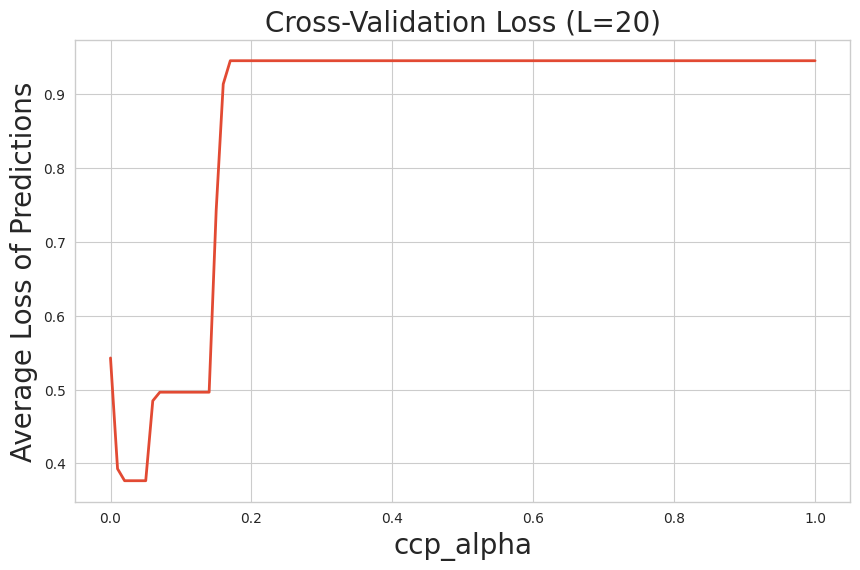


--- Running CV for L_FN = 50 ---

     ccp_alpha  AvgLoss (L=50)
0         0.00        1.195693
1         0.01        0.488856
2         0.02        0.488856
3         0.03        0.488856
4         0.04        0.577144
5         0.05        0.566605
6         0.06        0.566605
7         0.07        0.566605
8         0.08        0.566605
9         0.09        0.566605
10        0.10        0.566605
11        0.11        0.566605
12        0.12        0.566605
13        0.13        0.914533
14        0.14        0.941699
15        0.15        0.945212
16        0.16        0.945212
17        0.17        0.945212
18        0.18        0.945212
19        0.19        0.945212
20        0.20        0.945212
21        0.21        0.945212
22        0.22        0.945212
23        0.23        0.945212
24        0.24        0.945212
25        0.25        0.945212
26        0.26        0.945212
27        0.27        0.945212
28        0.28        0.945212
29        0.29        0.945212
30  

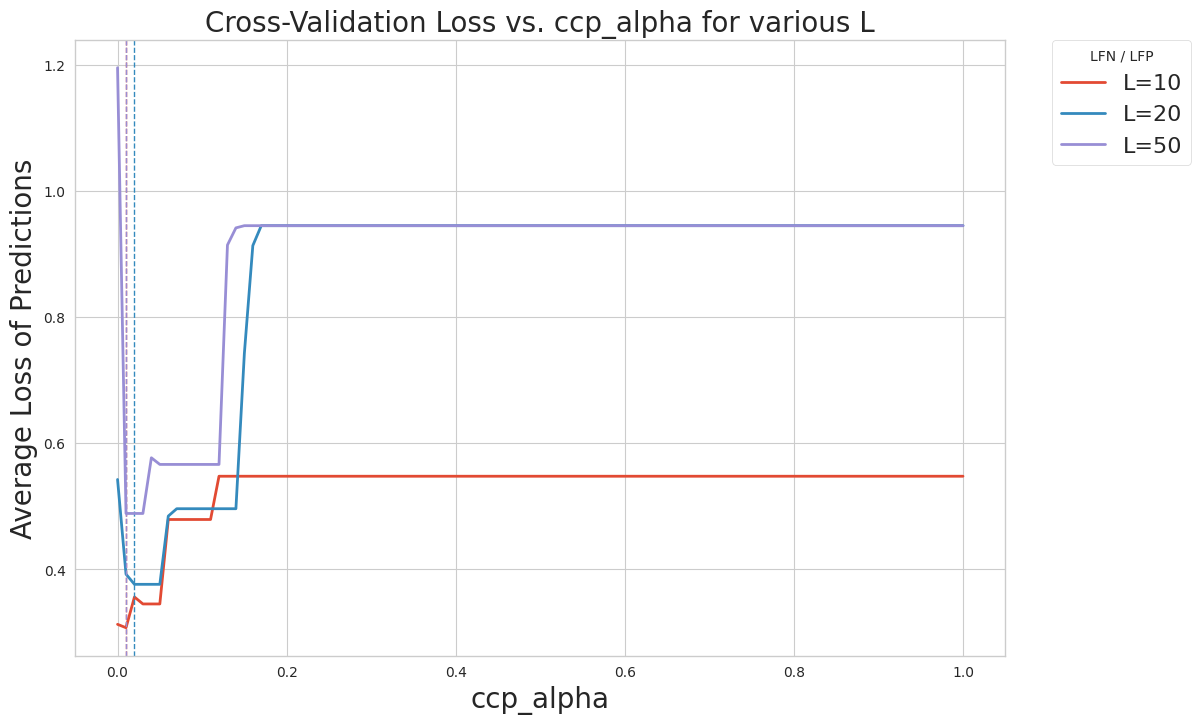

In [141]:
# --- 1. Loss Function and Scorer Definitions (Required for CV) ---

def raw_avg_loss(y_true, y_pred, L):
    """Calculates AvgLoss = (L_FP * FP + L_FN * FN) / Total Observations"""
    cm = confusion_matrix(y_true, y_pred)

    # Handles cases where a CV fold might miss one class
    if cm.shape == (1, 1):
        # We assume the user has robust data, but this handles edge cases
        return 0

    TN, FP, FN, TP = cm.ravel()

    L_FP = 1
    L_FN = L
    total_loss = (FP * L_FP) + (FN * L_FN)
    return total_loss / len(y_true)

def custom_avg_loss_scorer(L):
    """Returns a make_scorer object for GridSearchCV using the raw_avg_loss function."""
    # make_scorer minimizes the score by default (greater_is_better=False)
    return make_scorer(lambda y_true, y_pred: raw_avg_loss(y_true, y_pred, L), greater_is_better=False)


# --- 2. Run Full Cross-Validation Loop ---

L_all = [10, 20, 50]
cp_vals = np.linspace(0, 1, 101)
param_grid = {'ccp_alpha': cp_vals}

# Data structures to store results
cv_results_df = pd.DataFrame({'ccp_alpha': cp_vals})
cp_final = {}

print(f"Starting 10-fold Cross-Validation for L_FN in {L_all}...")

for L in L_all:
    print(f"\n--- Running CV for L_FN = {L} ---\n")

    # 1. Define the estimator with the loss matrix (class_weight)
    dt_cv = DecisionTreeClassifier(
        min_samples_leaf=5,
        class_weight={0: 1, 1: L}, # Differential loss L_FP=1, L_FN=L
        random_state=123
    )

    # 2. Define the scoring function
    loss_scorer = custom_avg_loss_scorer(L=L)

    # 3. Run GridSearchCV
    gcv = GridSearchCV(
        dt_cv,
        param_grid,
        cv=StratifiedKFold(10),
        scoring=loss_scorer,
        n_jobs=-1
    )
    gcv.fit(X_train, y_train)

    # 4. Extract results
    # mean_test_score is the average validation set loss (negated by make_scorer)
    avg_loss_values = -gcv.cv_results_['mean_test_score']

    # 5. Store results and optimal cp
    cv_results_df[f'AvgLoss (L={L})'] = avg_loss_values
#     print(cv_results_df)
    pd.set_option('display.max_rows', None)
    print(cv_results_df[['ccp_alpha', f'AvgLoss (L={L})']])
    pd.reset_option('display.max_rows')
    cp_final[L] = gcv.best_params_['ccp_alpha']

    # If L=20, generate the specific plot
    if L == 20:
        cv_results_L20 = pd.DataFrame({
            'ccp_alpha': gcv.cv_results_['param_ccp_alpha'].data,
            'AvgLoss': avg_loss_values
        })
        plt.figure(figsize=(10, 6))
        plt.plot(cv_results_L20['ccp_alpha'], cv_results_L20['AvgLoss'], linewidth=2)
        plt.xlabel("ccp_alpha", fontsize=20)
        plt.ylabel("Average Loss of Predictions", fontsize=20)
        plt.title("Cross-Validation Loss (L=20)", fontsize=20)
        plt.show()

print("\n--- Optimal ccp_alpha Values Found ---")
print(cp_final)
print("\n--- All CV Loss Curves Plot ---")

# Plot all CV curves
plt.figure(figsize=(12, 8))
for i, L in enumerate(L_all):
    plt.plot(cv_results_df['ccp_alpha'], cv_results_df[f'AvgLoss (L={L})'],
             label=f'L={L}',
             linewidth=2)
    # Add a marker for the optimal ccp_alpha
    plt.axvline(cp_final[L], color=plt.gca().lines[-1].get_color(), linestyle='--', linewidth=1)

plt.xlabel("ccp_alpha", fontsize=20)
plt.ylabel("Average Loss of Predictions", fontsize=20)
plt.title("Cross-Validation Loss vs. ccp_alpha for various L", fontsize=20)
# plt.legend(title='')
plt.legend(title='LFN / LFP', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=16)
plt.grid(True)
plt.show()


Final Tree for L=10 (cp=0.01):


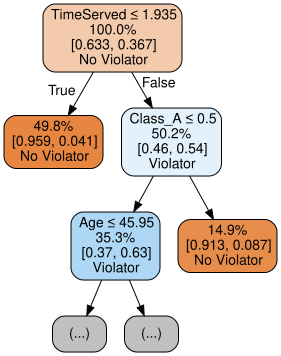


Final Tree for L=20 (cp=0.02):


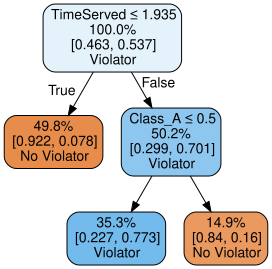


--- Sample Test Set Predictions (L=20) ---


,Violator,Male,Age,TimeServed,...,InCity,Pr(Yi=1),Violator Risk
2,0,1,24.9,2.25,...,0,0.772759,1
4,0,1,35.9,12.78,...,1,0.159574,0
5,0,1,25.9,1.18,...,1,0.078363,0
15,0,1,42.5,1.75,...,1,0.078363,0
36,0,0,48.3,0.75,...,1,0.078363,0
39,1,1,57.1,9.81,...,0,0.772759,1
40,0,1,47.3,20.11,...,0,0.772759,1
44,0,1,44.5,21.05,...,1,0.159574,0
...,...,...,...,...,...,...,...,...
6091,0,1,57.1,0.75,...,0,0.078363,0



--- Threshold 'What-If' Analysis (L=20) ---

Metrics for p_thres = 0.1:
Confusion Matrix:
[[917 813]
 [  5  96]]
  TPR (Sensitivity): 0.9505
  FPR (1-Specificity): 0.4699

--- Cumulative Plot of (FPR, TPR) points ---


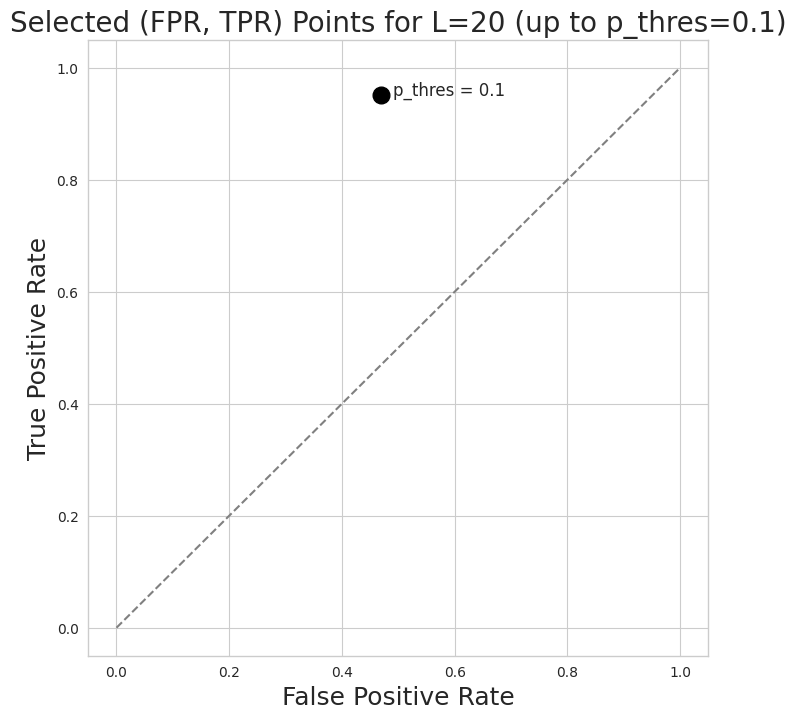


Metrics for p_thres = 0.5:
Confusion Matrix:
[[1184  546]
 [   7   94]]
  TPR (Sensitivity): 0.9307
  FPR (1-Specificity): 0.3156


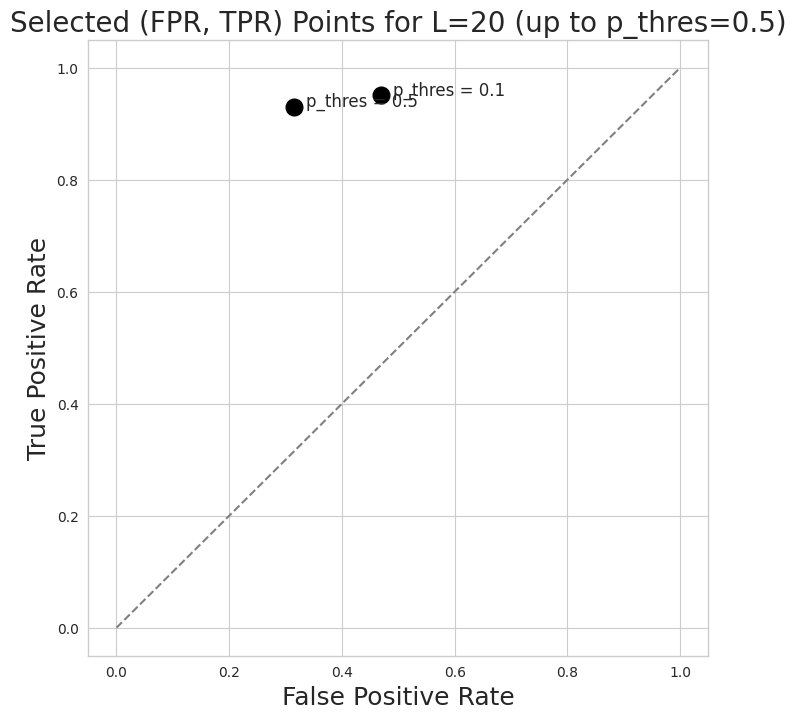


Metrics for p_thres = 0.3:
Confusion Matrix:
[[1184  546]
 [   7   94]]
  TPR (Sensitivity): 0.9307
  FPR (1-Specificity): 0.3156


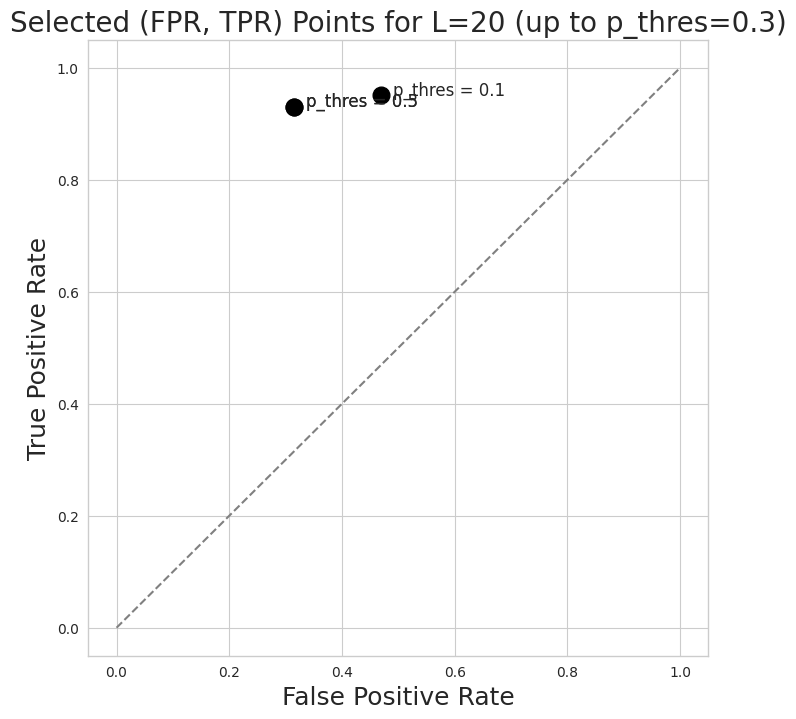


Metrics for p_thres = 0.7:
Confusion Matrix:
[[1184  546]
 [   7   94]]
  TPR (Sensitivity): 0.9307
  FPR (1-Specificity): 0.3156


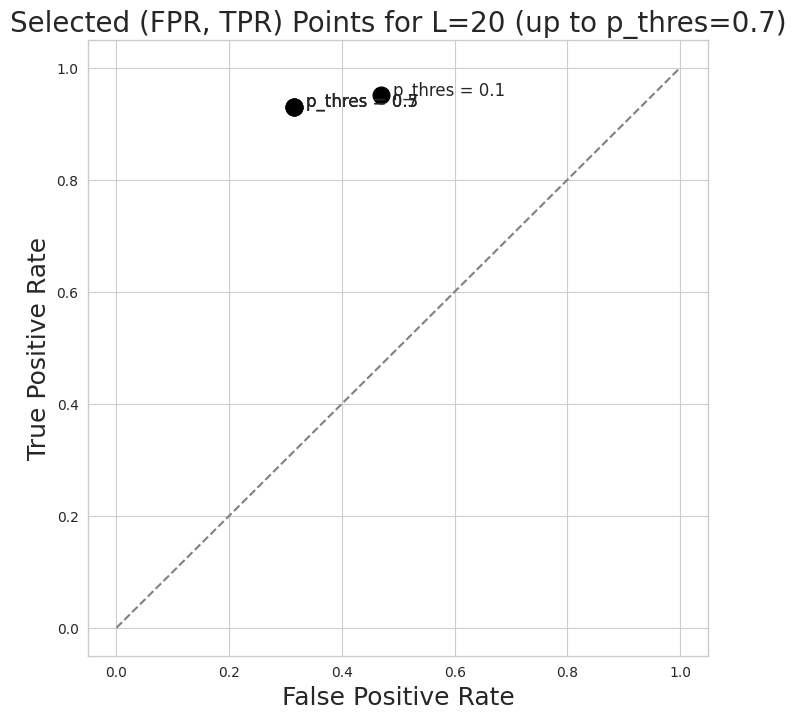


Metrics for p_thres = 0.9:
Confusion Matrix:
[[1730    0]
 [ 101    0]]
  TPR (Sensitivity): 0.0000
  FPR (1-Specificity): 0.0000


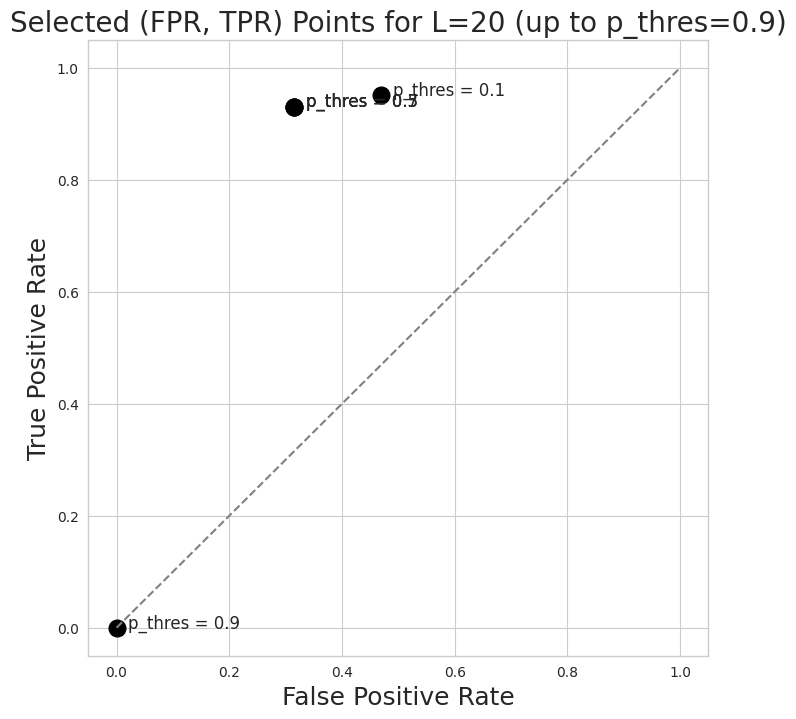


Final Tree for L=50 (cp=0.01):


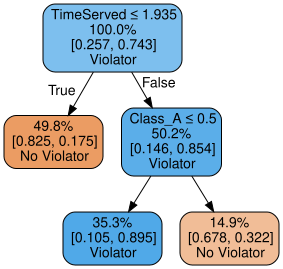

In [142]:
# Final assessment data structures
summary_list = []
rocr_pred_list = []

for L in L_all:
    ccp = cp_final[L]

    # 1. Fit Final Tree
    mod_final = DecisionTreeClassifier(
        min_samples_leaf=1,
        ccp_alpha=ccp,              # Optimal cp value
        class_weight={0: 1, 1: L},    # Custom loss matrix
    )
    mod_final.fit(X_train, y_train)

    # Optional: Plot final tree
    print(f"\nFinal Tree for L={L} (cp={ccp}):")

    # Using graphviz again
    dot_data = export_graphviz(
        mod_final,
        out_file=None,
        feature_names=X.columns.tolist(),
        class_names=['No Violator', 'Violator'],
        filled=True,
        rounded=True,
        proportion=True,
        special_characters=True,
        max_depth=2,
        impurity=False,
        label="none"
    )
    display(Source(dot_data))

    # 2. Prediction on Test Set

    # --- SET YOUR DESIRED PROBABILITY THRESHOLD ---
    # The default is 0.5 (which .predict() uses)
    p_thres = 0.5

    # First, get the weighted probabilities (P from your slides)
    pred_prob = mod_final.predict_proba(X_test)[:, 1] # Probability for class 1 (Violator)

    # Now, create pred_class by applying your custom threshold
    pred_class = (pred_prob > p_thres).astype(int)

    if L == 20:
        print("\n--- Sample Test Set Predictions (L=20) ---")

        # Create a DataFrame combining test features, true outcome, and predictions
        results_df = X_test.copy()
        results_df['True_Violator'] = y_test
        results_df['Predicted_Class'] = pred_class
        results_df['Predicted_Prob'] = pred_prob

        # --- Create the stubbed table for display ---

        # 1. Create a new DataFrame for display
        display_df = results_df.copy()

        # 2. Add the '...' column
        display_df['...'] = '...'

        # 3. Define the columns in the order you want
        cols_to_show = [
            'True_Violator',
            'Male',
            'Age',
            'TimeServed',
            '...',
            'InCity',
            'Predicted_Prob',
            'Predicted_Class'
        ]

        # 4. Filter and reorder the DataFrame
        display_df = display_df[cols_to_show]

        # 5. Rename columns to match the desired output
        display_df = display_df.rename(columns={
            'True_Violator': 'Violator',
            'Predicted_Prob': 'Pr(Yi=1)',
            'Predicted_Class': 'Violator Risk'
        })

        # 6. Use the existing show_head_tail function to print the new stubbed table
        show_head_tail(display_df.sort_index(), n=8, m=4)

        print("\n--- Threshold 'What-If' Analysis (L=20) ---")

        # List of thresholds you want to test
        thresholds_to_test = [0.1, 0.5, 0.3, 0.7, 0.9]

        # Lists to store the points for plotting
        fpr_list = []
        tpr_list = []

        # Flag to print header only once
        section_header_printed = False

        # Loop through each threshold and print the metrics
        for i, p_thres in enumerate(thresholds_to_test):
            print(f"\nMetrics for p_thres = {p_thres}:")

            # 1. Create temporary classifications based on the custom threshold
            temp_pred_class = (pred_prob > p_thres).astype(int)

            # 2. Calculate confusion matrix
            cm = confusion_matrix(y_test, temp_pred_class)
            TN, FP, FN, TP = cm.ravel()

            # 3. Calculate TPR and FPR (with a check for division by zero)
            tpr = TP / (TP + FN) if (TP + FN) > 0 else 0
            fpr = FP / (FP + TN) if (FP + TN) > 0 else 0

            # 4. Print the results
            print(f"Confusion Matrix:\n{cm}")
            print(f"  TPR (Sensitivity): {tpr:.4f}")
            print(f"  FPR (1-Specificity): {fpr:.4f}")

            # 5. Store the points for plotting
            fpr_list.append(fpr)
            tpr_list.append(tpr)

            # --- START: NEW CUMULATIVE PLOT BLOCK (INSIDE LOOP) ---
            if not section_header_printed:
                print("\n--- Cumulative Plot of (FPR, TPR) points ---")
                section_header_printed = True

            plt.figure(figsize=(8, 8))

            # Plot all (FPR, TPR) points collected SO FAR
            plt.plot(fpr_list, tpr_list, 'ko', markersize=12, label='Selected Thresholds')

            # Add text labels for all points collected SO FAR
            for j, thres in enumerate(thresholds_to_test[:i+1]):
                plt.text(fpr_list[j] + 0.02, tpr_list[j], f'p_thres = {thres}', fontsize=12)

            # Plot the baseline (random guess) line
            plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Baseline')

            # Formatting
            plt.xlabel("False Positive Rate", fontsize=18)
            plt.ylabel("True Positive Rate", fontsize=18)
            plt.title(f"Selected (FPR, TPR) Points for L={L} (up to p_thres={p_thres})", fontsize=20)
            plt.xlim(-0.05, 1.05)
            plt.ylim(-0.05, 1.05)
            plt.grid(True)
#             plt.legend(loc='lower right', fontsize=12)
            plt.show()
            # --- END: NEW CUMULATIVE PLOT BLOCK ---

    # 3. Confusion Matrix and Metrics
    cm = confusion_matrix(y_test, pred_class)
    # cm[1,2] -> FP; cm[2,1] -> FN
    TN, FP, FN, TP = cm.ravel()

    total_obs = len(y_test)
    accuracy = (TN + TP) / total_obs
    tpr = TP / (TP + FN) # True Positive Rate (Sensitivity)
    fpr = FP / (FP + TN) # False Positive Rate
    # Loss: L_FP*FP + L_FN*FN
    loss = FP * 1 + FN * L

    # 4. ROC and AUC
    fpr_roc, tpr_roc, _ = roc_curve(y_test, pred_prob)
    roc_auc = auc(fpr_roc, tpr_roc)

    # Store results
    summary_list.append({
        'L': L,
        'FP': FP,
        'TP': TP,
        'FN': FN,
        'TN': TN,
        'accuracy': accuracy,
        'tpr': tpr,
        'fpr': fpr,
        'loss': loss,
        'AUC': roc_auc
    })

    # Store ROC curve points for plotting
    rocr_pred_list.append(pd.DataFrame({'fpr': fpr_roc, 'tpr': tpr_roc, 'L': L}))

# Combine results into DataFrames
summary_df = pd.DataFrame(summary_list)
rocr_pred_df = pd.concat(rocr_pred_list)

### Performance metrics


--- Summary of Key Statistics on Test Set ---
     FP  TP  FN    TN  accuracy       tpr       fpr  loss       AUC
L                                                                  
10  190  71  30  1540  0.879847  0.702970  0.109827   490  0.876295
20  546  94   7  1184  0.697979  0.930693  0.315607   686  0.808971
50  546  94   7  1184  0.697979  0.930693  0.315607   896  0.808971

Final AUCs:
    L       AUC
0  10  0.876295
1  20  0.808971
2  50  0.808971


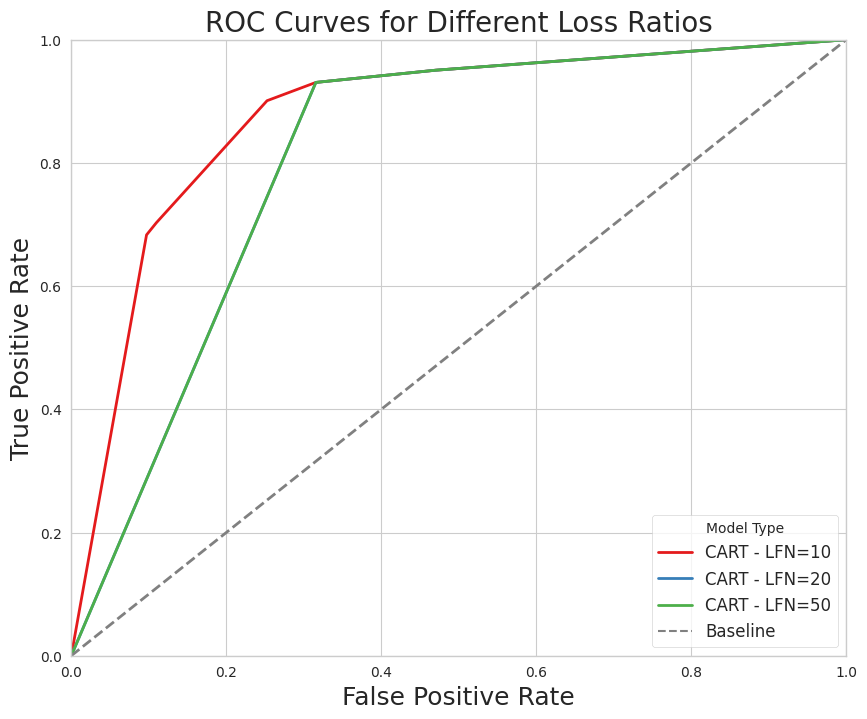

In [143]:
# Summary table
print("\n--- Summary of Key Statistics on Test Set ---")
print(summary_df.set_index('L'))

# Final AUC values
print("\nFinal AUCs:")
print(summary_df[['L', 'AUC']])

# ROC Plot
plt.figure(figsize=(10, 8))
sns.lineplot(
    data=rocr_pred_df,
    x='fpr',
    y='tpr',
    hue='L',
    palette='Set1',
    linewidth=2,
    legend='full'
)

# Baseline (y=x)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Baseline', linewidth=2)

plt.xlabel("False Positive Rate", fontsize=18)
plt.ylabel("True Positive Rate", fontsize=18)
plt.title("ROC Curves for Different Loss Ratios", fontsize=20)
plt.xlim(0, 1)
plt.ylim(0, 1)

# Custom Legend
legend_labels = {1: 'CART - LFN=1', 10: 'CART - LFN=10', 20: 'CART - LFN=20', 50: 'CART - LFN=50'}
handles, labels = plt.gca().get_legend_handles_labels()

# Reorder labels and add Baseline
new_labels = [legend_labels.get(int(l), f'L={l}') for l in summary_df['L']] + ['Baseline']
new_handles = handles[:len(summary_df['L'])] + [plt.Line2D([0], [0], linestyle='--', color='gray')]

plt.legend(new_handles, new_labels, title='Model Type', fontsize=12, loc='lower right')
plt.grid(True)
plt.show()


--- Summary of Key Statistics on Test Set ---
     FP  TP  FN    TN  accuracy       tpr       fpr  loss       AUC
L                                                                  
10  190  71  30  1540  0.879847  0.702970  0.109827   490  0.876295
20  546  94   7  1184  0.697979  0.930693  0.315607   686  0.808971
50  546  94   7  1184  0.697979  0.930693  0.315607   896  0.808971

Final AUCs:
    L       AUC
0  10  0.876295
1  20  0.808971
2  50  0.808971


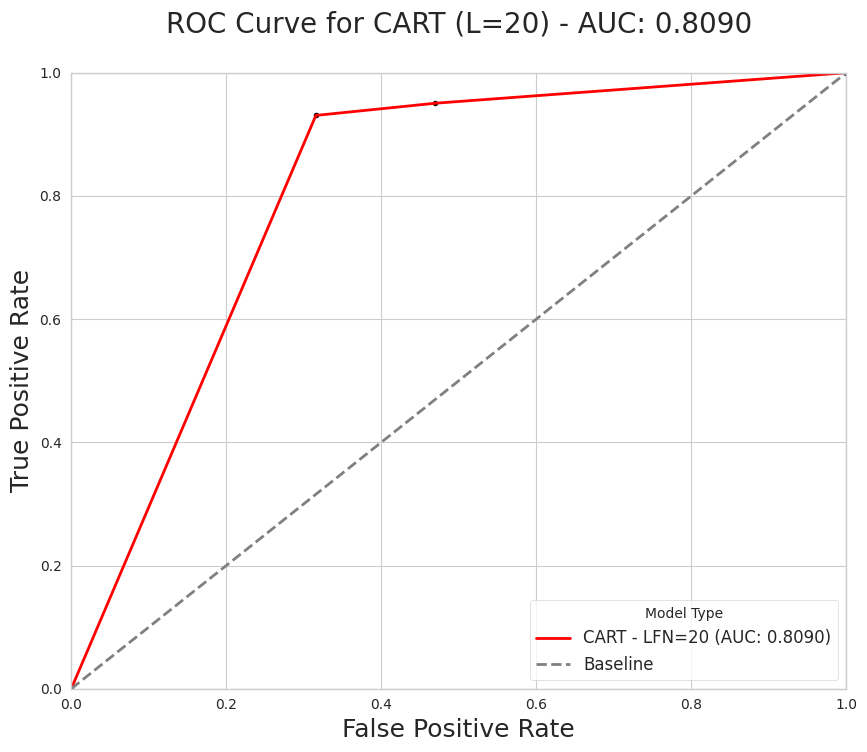

In [144]:
# Summary table
print("\n--- Summary of Key Statistics on Test Set ---")
print(summary_df.set_index('L'))

# Final AUC values
print("\nFinal AUCs:")
print(summary_df[['L', 'AUC']])

# --- Filtering the data for L=20 ---
rocr_pred_L20 = rocr_pred_df[rocr_pred_df['L'] == 20]
auc_L20 = summary_df.loc[summary_df['L'] == 20, 'AUC'].iloc[0]

# ROC Plot (L=20 only)
plt.figure(figsize=(10, 8))

# Use the filtered data for the plot
sns.lineplot(
    data=rocr_pred_L20,
    x='fpr',
    y='tpr',
    color='red', # Set a specific color since hue is removed
    linewidth=2
)

sns.scatterplot(
    data=rocr_pred_L20,
    x='fpr',
    y='tpr',
    color='black', # Set a specific color since hue is removed
    linewidth=2
)

# Baseline (y=x)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Baseline', linewidth=2)

plt.xlabel("False Positive Rate", fontsize=18)
plt.ylabel("True Positive Rate", fontsize=18)

# Update the title to include the calculated AUC value
plt.title(f"ROC Curve for CART (L=20) - AUC: {auc_L20:.4f}\n", fontsize=20)

plt.xlim(0, 1)
plt.ylim(0, 1)

# Custom Legend: Only need the L=20 curve and Baseline
plt.legend(
    handles=[
        plt.Line2D([0], [0], color='red', linewidth=2, label=f'CART - LFN=20 (AUC: {auc_L20:.4f})'),
        plt.Line2D([0], [0], linestyle='--', color='gray', linewidth=2, label='Baseline')
    ],
    title='Model Type',
    fontsize=12,
    loc='lower right'
)
plt.grid(True)
plt.show()

In [145]:
parole_train = X_train.copy()
parole_train['Violator'] = y_train

# --- Manual Node Check using the L=20 split logic on the training data ---

# Helper: Class == 'A' means all dummy variables for Class are 0
# This assumes Class_E exists in the data and was one-hot encoded
is_class_A = (parole_train['Class_B'] == 0) & \
             (parole_train['Class_C'] == 0) & \
             (parole_train['Class_D'] == 0)

# L1: parole.train$TimeServed < 1.94
L1 = parole_train['TimeServed'] < 1.94

# L2: TimeServed >= 1.94 & Class == "A"
L2 = (parole_train['TimeServed'] >= 1.94) & is_class_A

# L3: TimeServed >= 1.94 & Class != "A" & TimeServed >= 2.78
L3 = (parole_train['TimeServed'] >= 1.94) & (~is_class_A) & (parole_train['TimeServed'] >= 2.78)

# L4: TimeServed >= 1.94 & Class != "A" & TimeServed < 2.78 & (Class == "C" | Class == "D")
L4 = (parole_train['TimeServed'] >= 1.94) & \
     (parole_train['TimeServed'] < 2.78) & \
     ((parole_train['Class_C'] == 1) | (parole_train['Class_D'] == 1))

# L5: TimeServed >= 1.94 & Class != "A" & TimeServed < 2.78 & !(Class == "C" | Class == "D")
L5 = (parole_train['TimeServed'] >= 1.94) & \
     (parole_train['TimeServed'] < 2.78) & \
     ~is_class_A & \
     (parole_train['Class_C'] == 0) & \
     (parole_train['Class_D'] == 0)

nodes = {'L1': L1, 'L2': L2, 'L3': L3, 'L4': L4, 'L5': L5}

print("--- Counts and Proportions per Terminal Node (Violator: 0=No, 1=Yes) ---")
for name, condition in nodes.items():
    subset = parole_train[condition]['Violator']
    counts = subset.value_counts().sort_index()
    proportions = subset.value_counts(normalize=True).sort_index()

    print(f"\nNode {name}:")
    print("Counts:")
    print(counts)
    print("Proportions:")
    print(proportions)

print(f"\nProportion of TimeServed < 1.94: {L1.mean()}")

--- Counts and Proportions per Terminal Node (Violator: 0=No, 1=Yes) ---

Node L1:
Counts:
Violator
0    2117
1       9
Name: count, dtype: int64
Proportions:
Violator
0    0.995767
1    0.004233
Name: proportion, dtype: float64

Node L2:
Counts:
Violator
0    756
1     58
Name: count, dtype: int64
Proportions:
Violator
0    0.928747
1    0.071253
Name: proportion, dtype: float64

Node L3:
Counts:
Violator
0    800
1    156
Name: count, dtype: int64
Proportions:
Violator
0    0.83682
1    0.16318
Name: proportion, dtype: float64

Node L4:
Counts:
Violator
0    310
1      9
Name: count, dtype: int64
Proportions:
Violator
0    0.971787
1    0.028213
Name: proportion, dtype: float64

Node L5:
Counts:
Violator
0    54
1     2
Name: count, dtype: int64
Proportions:
Violator
0    0.964286
1    0.035714
Name: proportion, dtype: float64

Proportion of TimeServed < 1.94: 0.4977756965581831
